# Distances Between Multidimensional Distributions

This notebook provides practical metrics to compare **multidimensional distributions empirically** from samples.

It includes:
- **Maximum Mean Discrepancy (MMD)**
- **Sliced Wasserstein Distance**
- **Fréchet Distance** between Gaussian approximations
- a compact comparison table
- simple visual diagnostics after PCA projection

#### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import wasserstein_distance
from scipy.linalg import sqrtm
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA

### Generate two example multidimensional samples

You can replace these with your own samples:
- `X`: reference sample
- `Y`: generated / alternative sample

Each array must have shape `(n_samples, n_features)`.

In [2]:
rng = np.random.default_rng(42)

n_samples = 1000
n_features = 5

# Reference distribution
X = rng.normal(loc=0.0, scale=1.0, size=(n_samples, n_features))

# Alternative distribution: shifted mean + slightly different variance
Y = rng.normal(loc=0.3, scale=1.2, size=(n_samples, n_features))

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (1000, 5)
Y shape: (1000, 5)


## 1. Maximum Mean Discrepancy (MMD)

MMD is a kernel-based distance between distributions.  
It is very common in machine learning and generative modeling.

Here we use an Radial Basis Function (RBF) kernel, i.e.,
$$
    k(x,y) = \exp\big(-\gamma \|x - y\|^2\big)\;.
$$
Here, we compare distributions via:
$$
\mathbb{E}[k(X,X')] + \mathbb{E}[k(Y,Y')] - 2\mathbb{E}[k(X,Y)]
$$

In [3]:
def mmd_rbf(X, Y, gamma=1.0):
    X = np.asarray(X)
    Y = np.asarray(Y)

    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)

    return float(Kxx.mean() + Kyy.mean() - 2 * Kxy.mean())

mmd_value = mmd_rbf(X, Y, gamma=0.5)
print("MMD (RBF kernel):", mmd_value)

MMD (RBF kernel): 0.014476638970497613


### Choosing `gamma`

The result depends on the kernel bandwidth.  
A common simple heuristic is to use the **median pairwise distance**.

In [4]:
def median_heuristic_gamma(X, Y, max_points=300):
    X = np.asarray(X)
    Y = np.asarray(Y)
    Z = np.vstack([X, Y])

    if len(Z) > max_points:
        idx = np.random.choice(len(Z), size=max_points, replace=False)
        Z = Z[idx]

    dists = []
    for i in range(len(Z)):
        for j in range(i + 1, len(Z)):
            dists.append(np.sum((Z[i] - Z[j]) ** 2))
    median_sqdist = np.median(dists)
    return 1.0 / median_sqdist if median_sqdist > 0 else 1.0

gamma_med = median_heuristic_gamma(X, Y)
mmd_med = mmd_rbf(X, Y, gamma=gamma_med)

print("Median-heuristic gamma:", gamma_med)
print("MMD with median heuristic:", mmd_med)

Median-heuristic gamma: 0.08898339411245625
MMD with median heuristic: 0.03704401639915411


## 2. Sliced Wasserstein Distance

In high dimensions, exact Wasserstein distance is expensive.  
A common approximation is to:
1. project the data onto many random 1D directions,
2. compute 1D Wasserstein distance for each projection,
3. average the results.

This gives the **Sliced Wasserstein Distance**.

In [5]:
def sliced_wasserstein(X, Y, n_directions=100, seed=42):
    rng = np.random.default_rng(seed)
    X = np.asarray(X)
    Y = np.asarray(Y)

    d = X.shape[1]
    distances = []

    for _ in range(n_directions):
        theta = rng.normal(size=d)
        theta = theta / np.linalg.norm(theta)

        proj_X = X @ theta
        proj_Y = Y @ theta

        distances.append(wasserstein_distance(proj_X, proj_Y))

    return float(np.mean(distances))

sw_value = sliced_wasserstein(X, Y, n_directions=200, seed=42)
print("Sliced Wasserstein distance:", sw_value)

Sliced Wasserstein distance: 0.33265976019021126


## 3. Fréchet Distance Between Gaussian Approximations

This metric compares the two samples through their estimated mean and covariance.

It is exact if the two distributions are Gaussian, and often useful as a summary in practice.

This is closely related to the **FID** used in image generation.

In [6]:
def frechet_distance(X, Y):
    X = np.asarray(X)
    Y = np.asarray(Y)

    m1 = X.mean(axis=0)
    m2 = Y.mean(axis=0)

    C1 = np.cov(X, rowvar=False)
    C2 = np.cov(Y, rowvar=False)

    diff = m1 - m2
    covmean = sqrtm(C1 @ C2)

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    return float(diff @ diff + np.trace(C1 + C2 - 2 * covmean))

fid_like = frechet_distance(X, Y)
print("Fréchet distance:", fid_like)

Fréchet distance: 0.7717376003656216


#### A compact comparison table

In [7]:
results = pd.DataFrame({
    "metric": [
        "MMD (fixed gamma=0.5)",
        "MMD (median heuristic)",
        "Sliced Wasserstein",
        "Fréchet distance",
    ],
    "value": [
        mmd_value,
        mmd_med,
        sw_value,
        fid_like,
    ]
})

results

,metric,value
0,MMD (fixed gamma=0.5),0.014477
1,MMD (median heuristic),0.037044
2,Sliced Wasserstein,0.332660
3,Fréchet distance,0.771738


#### Visual diagnostic: PCA projection

This does **not** define a distance, but it is often useful to inspect the two clouds visually in 2D.

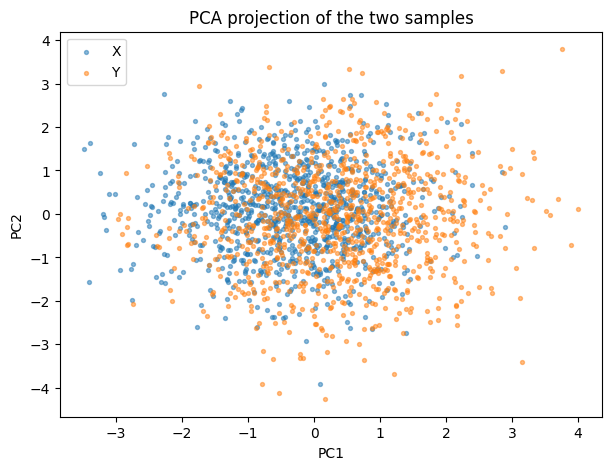

In [8]:
Z = np.vstack([X, Y])
labels = np.array(["X"] * len(X) + ["Y"] * len(Y))

pca = PCA(n_components=2)
Z_2d = pca.fit_transform(Z)

plt.figure(figsize=(7, 5))
plt.scatter(Z_2d[labels == "X", 0], Z_2d[labels == "X", 1], s=8, alpha=0.5, label="X")
plt.scatter(Z_2d[labels == "Y", 0], Z_2d[labels == "Y", 1], s=8, alpha=0.5, label="Y")
plt.title("PCA projection of the two samples")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

In [9]:
def compare_multivariate_distributions(X, Y, gamma=None, n_directions=100, seed=42):
    X = np.asarray(X)
    Y = np.asarray(Y)

    if gamma is None:
        gamma = median_heuristic_gamma(X, Y)

    return pd.DataFrame({
        "metric": [
            "MMD",
            "Sliced Wasserstein",
            "Fréchet distance",
        ],
        "value": [
            mmd_rbf(X, Y, gamma=gamma),
            sliced_wasserstein(X, Y, n_directions=n_directions, seed=seed),
            frechet_distance(X, Y),
        ]
    })

compare_multivariate_distributions(X, Y, n_directions=200)

,metric,value
0,MMD,0.037164
1,Sliced Wasserstein,0.332660
2,Fréchet distance,0.771738


## How to choose a metric in practice

### Good default choices
- **MMD**: very useful for general multidimensional comparison
- **Sliced Wasserstein**: useful when geometry matters
- **Fréchet distance**: useful if Gaussian approximation is acceptable

### If you care about tails
Add:
- marginal tail quantile comparisons,
- exceedance probabilities,
- tail dependence diagnostics.

### Important warning
Different metrics capture different aspects of discrepancy:
- mean / covariance shifts,
- nonlinear shape differences,
- support geometry,
- marginal vs joint structure.

It is usually better to report **several metrics**, not just one.